# Training the model

Everything upstream is now in place: notebook 1 produced the text, notebook 2 the tokenizer,
notebook 3 the model. This notebook feeds one into the other.

Training is the expensive step, and it is also the one that fails most quietly — a model
trained on misaligned targets, or evaluated against leaked data, produces a loss curve that
looks completely normal. So the checks come **before** the training loop, not after.

| Stage | What it produces |
| --- | --- |
| Load | tokenizer + model, agreeing on `vocab_size` |
| Encode | the corpus as one long tensor of token ids |
| Split | train / validation, with no window straddling the boundary |
| Check | target alignment, leakage, and that the model can learn at all |
| Pre-flight | measured seconds-per-step, so you know what you are committing to |
| Train | with gradient clipping and periodic evaluation |
| Save | a checkpoint that can actually be loaded again |


## Imports and paths

Both the tokenizer (`minbpe`) and the model (`transformer/model.py`) live outside this
folder, so the path setup has to happen before anything else. The original notebook did
`sys.path.append('..')` only, which reaches `transformer` but not `minbpe`.


In [1]:
import sys
from pathlib import Path

# The tutorial's own package (transformer/) sits one level up from Notebooks/.
tutorial_root = Path.cwd().parent
sys.path.insert(0, str(tutorial_root))

try:
    import minbpe
except ModuleNotFoundError:
    for repo_root in (Path.cwd(), *Path.cwd().parents):
        if (repo_root / "minbpe" / "minbpe" / "base.py").exists():
            sys.path.insert(0, str(repo_root / "minbpe"))
            print("using minbpe clone at:", repo_root / "minbpe")
            break
    else:
        raise ModuleNotFoundError(
            "minbpe not found. Install it with "
            "`pip install git+https://github.com/karpathy/minbpe.git`"
        )
else:
    print("using installed minbpe:", Path(minbpe.__file__).parent)

print("tutorial root:", tutorial_root)

using minbpe clone at: /Users/harshpujari/Documents/Work/Aexonic/Projects/llms/minbpe
tutorial root: /Users/harshpujari/Documents/Work/Aexonic/Projects/llms/TrainYourOwnLLM-Tutorial


In [2]:
import torch

from minbpe import RegexTokenizer
from transformer.model import GPTLanguageModel

torch.manual_seed(3647)

tokenizer = RegexTokenizer()
tokenizer.load(model_file="../output/tokenizer/my_tokenizer.model")


def get_vocab_size(tokenizer: RegexTokenizer) -> int:
    """Number of embedding rows the model needs: one past the largest usable id.

    Not len(vocab) + len(special_tokens). load() rebuilds .vocab with the special tokens
    already folded in, so that expression counts them twice - 1029 on a freshly trained
    tokenizer but 1034 on a reloaded one. The model would then be free to sample ids
    1029-1033, which no vocabulary entry covers, and generation would die with a
    ValueError inside decode().
    """
    largest = max(tokenizer.vocab)
    if tokenizer.special_tokens:
        largest = max(largest, *tokenizer.special_tokens.values())
    return largest + 1


vocab_size = get_vocab_size(tokenizer)
print(f"vocab_size = {vocab_size}")

vocab_size = 1029


## Configuration

### On `batch_size`, which is not a free parameter

Bigger batches are usually better — until they do not fit, at which point the machine starts
paging and throughput collapses. Measured on this model (13.8 M parameters, `block_size=256`)
on Apple MPS:

| `batch_size` | ms / step | estimated epoch |
| --- | --- | --- |
| 8 | 206 | 22 min |
| 32 | 794 | 22 min |
| **64** | **72,524** | **16.5 hours** |

8 → 32 scales linearly, which is what healthy scaling looks like: four times the work in four
times the time, same epoch duration. 64 is **91x** slower than 32 rather than 2x. That is not
compute, it is a memory cliff.

The original notebook used 64, which on this hardware turns a 22-minute epoch into a
16-hour one. It is set to 32 below. **This number is hardware-specific** — on a large CUDA
GPU, 64 is likely fine and better. The pre-flight cell further down measures your machine so
you find out in 30 seconds rather than after committing a night to it.

### On `max_epochs`, which is smaller than it looks

At `stride=1` an "epoch" is not one pass over the text. Every token position starts a window,
so with `block_size=256` each token appears in up to 256 different training samples:

    5,489 steps x 32 sequences x 256 tokens = 44.9M token-predictions
    ...over 175,922 distinct training tokens = ~256x oversampling

One epoch is therefore already a great deal of repetition. A second would be ~512x. For
reference, a 13.8M-parameter model is compute-optimal at roughly 276M tokens of *distinct*
text; this corpus has 176k. The model is data-starved by three orders of magnitude, so it will
overfit partway through the first epoch rather than after several.

That is why `max_epochs` stays at 1 and **validation loss decides when to stop**, via
`early_stop_patience` below. Raising `max_epochs` would just spend hours memorising.

### The rest

`n_embd=512, n_head=8, n_layer=4` differs from notebook 3's `384/6/6`. That is deliberate:
notebook 3 is for explaining, this one is for training.


In [3]:
block_size = 256
n_embd = 512
n_head = 8
n_layer = 4
dropout = 0.2

batch_size = 32          # see the table above before raising this
learning_rate = 3e-4
grad_clip = 1.0          # clip gradient norm; cheap insurance against loss spikes

eval_interval = 250      # steps between evaluations; see the note on evaluation overhead
eval_batches = 20        # training batches averaged per evaluation (validation uses all)
max_epochs = 1           # one pass at stride 1 already revisits every token ~256 times
max_steps = None         # None = run the full epoch; set an integer for a quick smoke test

early_stop_patience = 4  # stop after this many evaluations with no validation improvement

if torch.cuda.is_available():
    device = "cuda"
elif torch.backends.mps.is_available():
    device = "mps"       # without this branch an Apple machine silently trains on CPU
else:
    device = "cpu"

print(f"device = {device}")

device = mps


## Data

### Encoding

The corpus becomes one flat tensor of token ids. Nothing is batched yet — batching is the
data loader's job.


In [4]:
text_sequence = Path("../output/combined_text.txt").read_text(encoding="utf-8")
token_ids = tokenizer.encode(text_sequence)
data = torch.tensor(token_ids, dtype=torch.long)

print(f"{len(text_sequence):,} characters -> {len(data):,} tokens")

575,440 characters -> 195,469 tokens


### Train / validation split

A contiguous 90/10 split, not a random one. Random splitting would be wrong here: windows
overlap, so a randomly chosen validation window would share almost all of its tokens with
some training window, and the validation loss would measure memorisation rather than
generalisation.

**Know what your validation set actually contains.** The corpus is chats concatenated in
order, so the last 10% is not a representative sample — it is the tail of a single
conversation (`work_besties`). Validation loss here means "how well does it predict the end
of one chat it has partly seen", not "how well does it do on chat in general". That is still
a useful signal for overfitting; just do not read more into it than it says.


In [5]:
split_index = int(0.9 * len(data))
train_data = data[:split_index]
val_data = data[split_index:]

print(f"train {len(train_data):,} tokens")
print(f"val   {len(val_data):,} tokens")
print(f"\nvalidation set begins: {tokenizer.decode(val_data[:24].tolist())!r}")

train 175,922 tokens
val   19,547 tokens

validation set begins: " a 2 hour vent session don't remind me guys just checked my leave balance"


### Dataset and loaders

Each sample is a window of `block_size` tokens and the same window shifted one position
right. That shift is the entire learning signal: at every position the model sees the tokens
so far and is scored on the one that actually came next.

`stride` controls how far apart consecutive windows start. The default of 1 means every
token position begins a window — 52,325 training samples from 52,581 tokens, where each token
appears in up to 256 different windows. That is a lot of reuse for one pass; raising `stride`
trades samples for variety if you want faster epochs.

The whole tensor is moved to the device up front. It is a few hundred KB, so this removes
per-batch transfers entirely — which is also why `num_workers` stays 0, as worker processes
cannot share GPU tensors.


In [6]:
from torch.utils.data import DataLoader, Dataset


class TextDataset(Dataset):
    """Sliding windows over a flat token tensor, paired with their next-token targets."""

    def __init__(self, data: torch.Tensor, block_size: int, stride: int = 1) -> None:
        if len(data) <= block_size:
            raise ValueError(
                f"data length ({len(data)}) must be greater than block_size ({block_size})"
            )
        self.data = data
        self.block_size = block_size
        self.stride = stride

    def __len__(self) -> int:
        # The last valid start is len(data) - block_size - 1, because the target window
        # runs one position further than the input window.
        return (len(self.data) - self.block_size - 1) // self.stride + 1

    def __getitem__(self, index: int) -> tuple[torch.Tensor, torch.Tensor]:
        start = index * self.stride
        x = self.data[start : start + self.block_size]
        y = self.data[start + 1 : start + self.block_size + 1]
        return x, y


def get_dataloaders(train_data, val_data, block_size, batch_size, device,
                    train_stride=1, val_stride=None):
    # Validation uses stride=block_size so its windows are *disjoint*: one pass covers the
    # whole validation set exactly once, with no token predicted twice. At stride 1 the
    # first 20 val batches are 640 windows all starting within ~900 tokens of each other -
    # 163,840 predictions over 15% of the data, which is a lot of compute for a narrow and
    # heavily correlated estimate.
    val_stride = block_size if val_stride is None else val_stride

    train_loader = DataLoader(
        TextDataset(train_data.to(device), block_size, train_stride),
        batch_size=batch_size,
        shuffle=True,
        drop_last=True,      # keeps every step the same shape
    )
    val_loader = DataLoader(
        TextDataset(val_data.to(device), block_size, val_stride),
        batch_size=batch_size,
        shuffle=False,       # a fixed validation set makes losses comparable across steps
    )
    return train_loader, val_loader


train_loader, val_loader = get_dataloaders(
    train_data, val_data, block_size, batch_size, device
)
print(f"{len(train_loader)} train batches/epoch (stride 1)")
val_windows = len(val_loader.dataset)
val_covered = val_windows * block_size
print(f"{len(val_loader)} val batch(es): {val_windows} disjoint windows = "
      f"{val_covered:,} of {len(val_data):,} validation tokens predicted once each")
print(f"  (the trailing {len(val_data) - val_covered - 1} tokens do not start a full window)")

5489 train batches/epoch (stride 1)
3 val batch(es): 76 disjoint windows = 19,456 of 19,547 validation tokens predicted once each
  (the trailing 90 tokens do not start a full window)


### Check the data before training on it

Three assertions. The first is the one that matters most in the whole notebook.

1. **Targets are the inputs shifted by exactly one.** Off-by-one here and the model learns to
   predict the *current* token instead of the next one, or skips one entirely. Either way it
   trains happily and the loss falls. Nothing tells you except output that never makes sense.

2. **No window runs off the end of the tensor.** The last window is the easy off-by-one to
   get wrong, so the last index is checked explicitly rather than trusted.

3. **No overlap between train and validation.** They come from disjoint slices, so a
   validation window can never contain a training token.


In [7]:
check_dataset = TextDataset(train_data, block_size)

# 1. y is x shifted left by one, at the first, a middle, and the very last index
for index in (0, len(check_dataset) // 2, len(check_dataset) - 1):
    x, y = check_dataset[index]
    assert x.shape == y.shape == (block_size,), (index, x.shape, y.shape)
    assert torch.equal(y[:-1], x[1:]), f"targets misaligned at index {index}"

# 2. the final window must fit inside the tensor
last_start = (len(check_dataset) - 1) * check_dataset.stride
assert last_start + block_size + 1 <= len(train_data), "last window runs past the end"

# 3. train and validation share no tokens
assert split_index + len(val_data) == len(data)
assert torch.equal(torch.cat([train_data, val_data]), data), "split lost or duplicated tokens"

x, y = next(iter(train_loader))
print(f"batch shapes      x {tuple(x.shape)}  y {tuple(y.shape)}")
print(f"targets aligned   y[i] == x[i+1] at first, middle and last window")
print(f"last window ends  {last_start + block_size + 1} <= {len(train_data)} tokens")
print(f"\nx[:8] {x[0][:8].tolist()}")
print(f"y[:8] {y[0][:8].tolist()}   <- same sequence, shifted one left")

batch shapes      x (32, 256)  y (32, 256)
targets aligned   y[i] == x[i+1] at first, middle and last window
last window ends  175922 <= 175922 tokens

x[:8] [44, 860, 105, 358, 264, 272, 259, 459]
y[:8] [860, 105, 358, 264, 272, 259, 459, 805]   <- same sequence, shifted one left


## The model

Imported from `transformer/model.py` — the same code notebook 3 explains and verifies.

`torch.compile` is deliberately **not** applied. It costs about 7 seconds of compilation
here, warns on MPS, and — the real problem — wraps the model so that every `state_dict` key
gains an `_orig_mod.` prefix. A checkpoint saved that way cannot be loaded into a plain
`GPTLanguageModel` without stripping the prefix first, which is a confusing failure to hit
after a long training run. `save_checkpoint` below unwraps it defensively anyway, so you can
turn compilation on if you benchmark it as a win on your hardware.


In [8]:
model = GPTLanguageModel(
    vocab_size=vocab_size,
    block_size=block_size,
    n_embd=n_embd,
    n_head=n_head,
    n_layer=n_layer,
    dropout=dropout,
).to(device)

optimizer = torch.optim.AdamW(model.parameters(), lr=learning_rate)

print(f"{sum(p.numel() for p in model.parameters()) / 1e6:.2f} M parameters")

13.79 M parameters


### Can it learn at all?

The single most useful test before a real training run: take **one** batch and train on it
repeatedly. A working model will drive the loss on one batch close to zero within a few dozen
steps, because it has more than enough capacity to memorise 32 sequences.

If the loss does *not* collapse here, no amount of training on the full corpus will help —
the problem is the model, the optimiser or the data plumbing, and you have found it in
fifteen seconds rather than after an epoch.

The model and optimiser used for this are throwaway copies, so the real ones start clean.


In [ ]:
import math

probe_model = GPTLanguageModel(
    vocab_size=vocab_size, block_size=block_size, n_embd=n_embd,
    n_head=n_head, n_layer=n_layer, dropout=0.0,      # no dropout: we WANT to overfit
).to(device)
probe_optimizer = torch.optim.AdamW(probe_model.parameters(), lr=1e-3)

x_one, y_one = next(iter(train_loader))
probe_model.train()

probe_history = []
for step in range(60):
    _, loss = probe_model(x_one, y_one)
    probe_optimizer.zero_grad(set_to_none=True)
    loss.backward()
    probe_optimizer.step()
    probe_history.append(loss.item())

print(f"step  0: {probe_history[0]:.3f}   (untrained, ~ln({vocab_size}) = {math.log(vocab_size):.3f})")
print(f"step 20: {probe_history[20]:.3f}")
print(f"step 59: {probe_history[-1]:.3f}")

assert probe_history[-1] < probe_history[0] / 2, (
    f"loss on a single batch went {probe_history[0]:.3f} -> {probe_history[-1]:.3f}; "
    "the model cannot memorise one batch, so something upstream is broken"
)
print("\nthe model can fit a single batch - the plumbing works")

del probe_model, probe_optimizer

### Pre-flight: what am I committing to?

Time a handful of real steps and extrapolate. Thirty seconds here tells you whether the run
ahead is twenty minutes or sixteen hours — which is exactly the difference `batch_size=64`
made on this machine.

The synchronise call is not optional. CUDA and MPS queue work asynchronously, so without it
you measure how fast Python can submit kernels, not how long they take.


In [40]:
import time


def synchronize(device: str) -> None:
    if device == "cuda":
        torch.cuda.synchronize()
    elif device == "mps":
        torch.mps.synchronize()


def time_steps(model, optimizer, loader, repeats=5):
    batches = [b for _, b in zip(range(repeats + 1), loader)]
    model.train()

    def one_step(x, y):
        _, loss = model(x, y)
        optimizer.zero_grad(set_to_none=True)
        loss.backward()
        torch.nn.utils.clip_grad_norm_(model.parameters(), grad_clip)
        optimizer.step()

    one_step(*batches[0])                       # warm-up, not timed
    synchronize(device)
    start = time.perf_counter()
    for x, y in batches[1:]:
        one_step(x, y)
    synchronize(device)
    return (time.perf_counter() - start) / repeats


# Throwaway copies. Timing the real model would leave it six optimiser steps into
# training before the loop below reports "step 0" - the curve would not start near
# ln(vocab_size), and the first number printed would be quietly wrong.
timing_model = GPTLanguageModel(
    vocab_size=vocab_size, block_size=block_size, n_embd=n_embd,
    n_head=n_head, n_layer=n_layer, dropout=dropout,
).to(device)
timing_optimizer = torch.optim.AdamW(timing_model.parameters(), lr=learning_rate)

seconds_per_step = time_steps(timing_model, timing_optimizer, train_loader)
steps_per_epoch = len(train_loader)

del timing_model, timing_optimizer

print(f"{seconds_per_step * 1000:.0f} ms/step at batch_size={batch_size}")
print(f"{steps_per_epoch} steps/epoch -> {seconds_per_step * steps_per_epoch / 60:.1f} min per full epoch")
if max_steps is not None:
    print(f"\nmax_steps={max_steps}, so this run will take about "
          f"{seconds_per_step * max_steps / 60:.1f} min plus evaluation")

885 ms/step at batch_size=32
5489 steps/epoch -> 81.0 min per full epoch


## Training

Two things the original loop did not do:

**Gradient clipping.** One bad batch can produce a huge gradient that throws the weights into
a region the optimiser needs hundreds of steps to recover from. Clipping the global norm to
1.0 costs almost nothing and removes that failure mode.

**A bounded evaluation.** The original averaged 88 training batches and 88 validation batches
every 100 steps — 176 extra forward passes per 100 training steps, a large fraction of total
compute spent on a number a few batches estimate just as well.

The training estimate is now capped at `eval_batches` drawn from the shuffled loader. The
validation loader is built with **disjoint** windows, so a complete pass over the held-out set
is a single batch — cheaper *and* more meaningful, because it covers all 5,843 validation
tokens rather than the first ~900. Overlapping windows inflate the number of predictions
without adding information.

`estimate_loss` also restores whatever mode the model was in rather than assuming `train()`.

**Evaluation spacing.** Each evaluation is 23 forward passes, about 3.8 s. At
`eval_interval=20` a 5,489-step epoch runs 274 of them — **18 minutes, 19% of the run**, for a
curve far denser than anyone reads. At 250 it is 21 evaluations, about 1 minute, 2%.

**Early stopping and the best checkpoint.** Two things a long run needs that a 60-step smoke
test does not:

- The checkpoint is written **whenever validation improves**, not once at the end. Otherwise a
  run that peaks at step 2,000 and drifts for another 3,000 saves the drifted weights.
- Training stops after `early_stop_patience` evaluations with no improvement, and the best
  weights are loaded back into `model` before anything downstream uses it. So the text
  generated at the bottom comes from the best model, not the last one.


In [41]:
@torch.no_grad()
def estimate_loss(model, loaders: dict, eval_batches: int) -> dict:
    """Average loss over a fixed number of batches from each loader."""
    was_training = model.training
    model.eval()
    try:
        results = {}
        for split, loader in loaders.items():
            losses = []
            for _, (x, y) in zip(range(eval_batches), loader):
                _, loss = model(x, y)
                losses.append(loss.item())
            results[split] = sum(losses) / len(losses)
        return results
    finally:
        model.train(was_training)


def save_checkpoint(model, optimizer, epoch, step, loss, file_path) -> None:
    """Write a checkpoint that a plain GPTLanguageModel can load.

    torch.compile wraps the model, prefixing every state_dict key with '_orig_mod.'.
    Unwrapping here means the checkpoint stays loadable whether or not compilation
    was used. The directory is created rather than assumed - the original wrote to
    ../output/pre_training/run_4/, which does not exist, so the very first save
    raised FileNotFoundError after a full epoch of training had already happened.
    """
    file_path = Path(file_path)
    file_path.parent.mkdir(parents=True, exist_ok=True)

    torch.save(
        {
            "epoch": epoch,
            "step": step,
            "loss": loss,
            "model_state_dict": getattr(model, "_orig_mod", model).state_dict(),
            "optimizer_state_dict": optimizer.state_dict(),
            "config": {
                "vocab_size": vocab_size, "block_size": block_size, "n_embd": n_embd,
                "n_head": n_head, "n_layer": n_layer, "dropout": dropout,
            },
        },
        file_path,
    )
    return file_path

In [42]:
loaders = {"train": train_loader, "val": val_loader}
history = {"step": [], "train": [], "val": []}
checkpoint_path = Path("../output/pre_training/run_4/checkpoint.pth")

total_steps = max_steps if max_steps is not None else steps_per_epoch * max_epochs
global_step = 0
best_val = float("inf")
best_step = -1
stale_evals = 0
stop = False

model.train()
start_time = time.perf_counter()

for epoch in range(max_epochs):
    if stop:
        break
    for x_batch, y_batch in train_loader:
        if max_steps is not None and global_step >= max_steps:
            stop = True
            break

        if global_step % eval_interval == 0:
            # Step 0 should land near ln(vocab_size) = 6.94. If it is meaningfully lower,
            # something upstream has already updated the weights.
            losses = estimate_loss(model, loaders, eval_batches)
            history["step"].append(global_step)
            history["train"].append(losses["train"])
            history["val"].append(losses["val"])

            improved = losses["val"] < best_val
            if improved:
                best_val, best_step, stale_evals = losses["val"], global_step, 0
                save_checkpoint(model, optimizer, epoch, global_step, best_val, checkpoint_path)
            else:
                stale_evals += 1

            elapsed = time.perf_counter() - start_time
            remaining = elapsed * (total_steps - global_step) / global_step if global_step else 0
            print(
                f"step {global_step:>5}/{total_steps}  "
                f"train {losses['train']:.4f}  val {losses['val']:.4f}"
                f"{'  <- best, saved' if improved else f'  ({stale_evals}/{early_stop_patience} stale)'}"
                f"   [{elapsed / 60:.0f}m elapsed, ~{remaining / 60:.0f}m left]"
            )

            if stale_evals >= early_stop_patience:
                print(
                    f"\nvalidation loss has not improved for {early_stop_patience} "
                    f"evaluations - stopping early at step {global_step}"
                )
                stop = True
                break

        _, loss = model(x_batch, y_batch)
        optimizer.zero_grad(set_to_none=True)
        loss.backward()
        torch.nn.utils.clip_grad_norm_(model.parameters(), grad_clip)
        optimizer.step()
        global_step += 1

# Final measurement so the curve ends on a real point rather than mid-interval.
losses = estimate_loss(model, loaders, eval_batches)
history["step"].append(global_step)
history["train"].append(losses["train"])
history["val"].append(losses["val"])
if losses["val"] < best_val:
    best_val, best_step = losses["val"], global_step
    save_checkpoint(model, optimizer, max_epochs - 1, global_step, best_val, checkpoint_path)

print(f"\n{global_step} steps in {(time.perf_counter() - start_time) / 60:.1f} min")
print(f"best validation loss {best_val:.4f} at step {best_step}")

# Load the best weights back, so generation below uses them and not whatever the last
# step happened to leave behind.
best = torch.load(checkpoint_path, map_location=device, weights_only=False)
model.load_state_dict(best["model_state_dict"])
saved = checkpoint_path
print(f"checkpoint -> {saved.resolve()} ({saved.stat().st_size / 1e6:.1f} MB), "
      f"best weights restored into `model`")

step     0/5489  train 7.0496  val 7.0685  <- best, saved    elapsed, ~0m left]
step   250/5489  train 3.9457  val 4.5704  <- best, saved    elapsed, ~76m left]
step   500/5489  train 3.2212  val 4.5555  <- best, saved    elapsed, ~75m left]
step   750/5489  train 2.3268  val 4.6538  (1/4 stale)    elapsed, ~73m left]
step  1000/5489  train 1.5818  val 4.9736  (2/4 stale)    elapsed, ~70m left]
step  1250/5489  train 0.9735  val 5.4025  (3/4 stale)    elapsed, ~67m left]
step  1500/5489  train 0.6009  val 5.8101  (4/4 stale)    elapsed, ~64m left]

validation loss has not improved for 4 evaluations - stopping early at step 1500

1500 steps in 24.0 min
best validation loss 4.5555 at step 500
checkpoint -> /Users/harshpujari/Documents/Work/Aexonic/Projects/llms/TrainYourOwnLLM-Tutorial/output/pre_training/run_4/checkpoint.pth (165.5 MB), best weights restored into `model`


### Check the checkpoint can actually be loaded

A checkpoint you cannot restore is not a checkpoint. This is worth asserting immediately
after writing it, while the fix is cheap, rather than discovering it days later.


In [43]:
restored = GPTLanguageModel(
    vocab_size=vocab_size, block_size=block_size, n_embd=n_embd,
    n_head=n_head, n_layer=n_layer, dropout=dropout,
).to(device)

checkpoint = torch.load(saved, map_location=device, weights_only=False)
restored.load_state_dict(checkpoint["model_state_dict"])   # raises on any key mismatch

model.eval(); restored.eval()
probe = next(iter(val_loader))[0][:2]
with torch.no_grad():
    difference = (model(probe)[0] - restored(probe)[0]).abs().max().item()
assert difference == 0.0, f"restored model differs from the trained one by {difference}"

print(f"restored from checkpoint, outputs identical (max difference {difference})")
print(f"saved config: {checkpoint['config']}")

del restored
model.train()   # returns self; keep it off the last line so the repr is not echoed
None


restored from checkpoint, outputs identical (max difference 0.0)
saved config: {'vocab_size': 1029, 'block_size': 256, 'n_embd': 512, 'n_head': 8, 'n_layer': 4, 'dropout': 0.2}


## The loss curve

What to look for: training loss falling is only half the story. The moment **validation loss
flattens or turns up while training loss keeps falling**, the model has started memorising
rather than learning, and further training makes it worse. On a corpus this small that
happens early.


Python(26442) MallocStackLogging: can't turn off malloc stack logging because it was not enabled.
Python(26443) MallocStackLogging: can't turn off malloc stack logging because it was not enabled.
Matplotlib is building the font cache; this may take a moment.


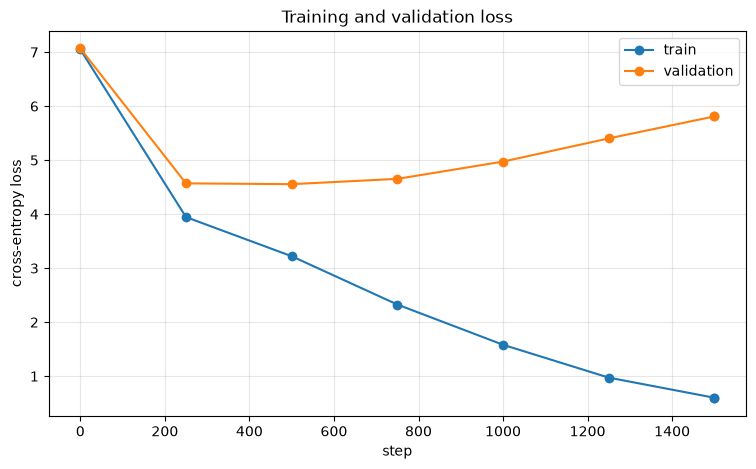

In [44]:
try:
    import matplotlib.pyplot as plt
except ModuleNotFoundError:
    print("matplotlib is not installed - `pip install matplotlib` for the chart.\n")
    print(f"{'step':>8}{'train':>10}{'val':>10}")
    for s, t, v in zip(history["step"], history["train"], history["val"]):
        print(f"{s:>8}{t:>10.4f}{v:>10.4f}")
else:
    figure, axis = plt.subplots(figsize=(9, 5))
    axis.plot(history["step"], history["train"], marker="o", label="train")
    axis.plot(history["step"], history["val"], marker="o", label="validation")
    axis.set_xlabel("step")
    axis.set_ylabel("cross-entropy loss")
    axis.set_title("Training and validation loss")
    axis.legend()
    axis.grid(alpha=0.3)
    plt.show()

## Generating text

The original prompt here was `"Salam labas "`, which is a leftover from the tutorial this was
adapted from — neither word appears anywhere in the corpus, so the model has never seen
either and the sample says nothing about how training went. A prompt drawn from the actual
chats is a far more honest test.

`eos_token_id` is passed so generation stops when the model produces `<|endoftext|>` instead
of always running to `max_new_tokens`. That only works because notebook 2 made it a single
token id.

After a short run the output will still be mostly noise. What to watch for is *structure*
appearing before meaning: real words, plausible spacing, names from the chats.


In [ ]:
def complete(prompt: str, max_new_tokens: int = 80, temperature: float = 0.8) -> str:
    input_tokens = torch.tensor([tokenizer.encode(prompt)], dtype=torch.long, device=device)
    output = model.generate(
        input_tokens=input_tokens,
        max_new_tokens=max_new_tokens,
        temperature=temperature,
        eos_token_id=tokenizer.special_tokens["<|endoftext|>"],
    )
    return tokenizer.decode(output[0].tolist())


for prompt in ("hey ", "are you coming", "what about "):
    print(f"--- {prompt!r}")
    print(complete(prompt), "\n")

--- 'hey '
hey Vera, so you know if you know. happy new family. Aple. Happy! Looks. Fathering win. Did you eat breakfast. yes had the budgetable in cake this, we'll come home, will beves Book. ent, enjoy is choy Ble 

--- 'are you coming'
are you coming to myself that, chates now broke in years of it's literally me WAT WAY AINT WEREDHAS! whatever happens for once you're ner� ITHATHAY that celebration happy dived, I would believe it whatever 

--- 'what about '
what about 214, companyed and bump, budgeting size match size I can someone starts 12 to tell meancome 36, quote, watchmanp classical, still enjoyp still stair point schedues 180 for now good to  



ERROR:tornado.general:Uncaught exception in ZMQStream callback
Traceback (most recent call last):
  File "/Users/harshpujari/Documents/Work/Aexonic/Projects/llms/.venv/lib/python3.14/site-packages/zmq/eventloop/zmqstream.py", line 565, in _log_error
    f.result()
    ~~~~~~~~^^
  File "/Users/harshpujari/Documents/Work/Aexonic/Projects/llms/.venv/lib/python3.14/site-packages/ipykernel/kernelbase.py", line 348, in dispatch_control
    await self.process_control(msg)
  File "/Users/harshpujari/Documents/Work/Aexonic/Projects/llms/.venv/lib/python3.14/site-packages/ipykernel/kernelbase.py", line 354, in process_control
    idents, msg = self.session.feed_identities(msg, copy=False)
                  ~~~~~~~~~~~~~~~~~~~~~~~~~~~~^^^^^^^^^^^^^^^^^
  File "/Users/harshpujari/Documents/Work/Aexonic/Projects/llms/.venv/lib/python3.14/site-packages/jupyter_client/session.py", line 998, in feed_identities
    raise ValueError(msg)
ValueError: DELIM not in msg_list
ERROR:tornado.general:Uncaught 

### Where to go next

- **Read the gap, not the training loss.** When validation stops falling while training keeps
  going, the model is memorising. Early stopping above acts on exactly that.
- **More distinct text beats more steps.** At ~176k training tokens this model is data-starved
  by roughly three orders of magnitude; another export helps far more than another epoch.
- **If you want faster epochs**, raise `train_stride` in `get_dataloaders`. At stride 8 an
  epoch is ~690 steps instead of 5,489, with each token still seen ~32 times — a much better
  ratio of wall-clock to new information.
- **The checkpoint is 165 MB**, two thirds of which is AdamW state needed only to resume. Save
  `model_state_dict` alone if you just want to run inference.